In [18]:
#Install dependencies
!pip install -q transformers accelerate bitsandbytes pillow torch torchvision tqdm sentencepiece

In [2]:
# Cell 2: Import libraries and load the model
import torch
from transformers import LlavaProcessor, LlavaForConditionalGeneration, BitsAndBytesConfig

# Define the model ID
model_id = "llava-hf/llava-1.5-7b-hf"

# Configure 4-bit quantization
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16
)

print("Loading Processor...")
processor = LlavaProcessor.from_pretrained(model_id)

print("Loading Model in 4-bit (this may take a minute)...")
model = LlavaForConditionalGeneration.from_pretrained(
    model_id,
    quantization_config=bnb_config,
    device_map="auto" # Automatically places layers on the GPU
)
print("Model loaded successfully!")

Loading Processor...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


processor_config.json:   0%|          | 0.00/173 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/701 [00:00<?, ?B/s]

chat_template.jinja:   0%|          | 0.00/674 [00:00<?, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/686 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/141 [00:00<?, ?B/s]

Model loaded successfully!


In [3]:
# Cell 3 Unzip benchmark folders

import os

if not os.path.exists("/content/MME_Benchmark_Subset"):
    !unzip -q /content/MME_Benchmark_Subset.zip -d /content/MME_Benchmark_Subset

if not os.path.exists("/content/POPE_Final_Subset"):
    !unzip -q /content/POPE_Final_Subset.zip -d /content/POPE_Final_Subset


if not os.path.exists("/content/mmvp_subset_50"):
    !unzip -q /content/mmvp_subset_50.zip -d /content/mmvp_subset_50


In [4]:
# Cell 4: Data Loading Function
import json
import os

def load_benchmark_data(base_dir):
    """
    Reads the benchmark-questions.jsonl file from the given directory.
    Returns a list of dictionaries containing image paths, questions, and ground truths.
    """
    jsonl_path = os.path.join(base_dir, "benchmark-questions.jsonl")
    data = []

    if not os.path.exists(jsonl_path):
        print(f"Warning: {jsonl_path} not found.")
        return data

    with open(jsonl_path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if line:
                item = json.loads(line)
                image_filename = item.get("image", "")

                # Check for image inside an 'images' subfolder, otherwise check the root dir
                img_path = os.path.join(base_dir, "images", image_filename)
                if not os.path.exists(img_path):
                    img_path = os.path.join(base_dir, image_filename)

                item["full_image_path"] = img_path
                data.append(item)

    return data

In [5]:
# Cell 5: Inference and Evaluation Engine
from PIL import Image
from tqdm import tqdm

def evaluate_benchmark(benchmark_name, data):
    """
    Iterates through the dataset, generates answers using LLaVA,
    and compares them to the ground truth.
    """
    correct = 0
    total = len(data)

    if total == 0:
        print(f"No data to evaluate for {benchmark_name}.")
        return 0.0

    for item in tqdm(data, desc=f"Evaluating {benchmark_name}"):
        img_path = item["full_image_path"]
        question = item.get("question", "")
        # Handle cases where the ground truth is stored under 'answer' or 'label'
        ground_truth = str(item.get("answer", item.get("label", ""))).strip().lower()

        # 1. Load the Image safely
        try:
            raw_image = Image.open(img_path).convert("RGB")
        except Exception as e:
            print(f"\nError loading image {img_path}: {e}. Skipping...")
            total -= 1 # Adjust total so skipped images don't penalize accuracy unfairly
            continue

        # 2. Format the prompt for LLaVA v1.5
        # The standard format is: "USER: <image>\n{question}\nASSISTANT:"
        prompt = f"USER: <image>\n{question}\nASSISTANT:"

        # 3. Process inputs
        inputs = processor(
          text=prompt,
          images=raw_image,
          return_tensors="pt"
        )

        inputs = {k: v.to(model.device) for k, v in inputs.items()}

        # 4. Generate Answer
        with torch.inference_mode():
            # Use greedy decoding (temperature=0) for reproducible benchmark evaluation
            output_ids = model.generate(
                **inputs,
                max_new_tokens=20,
                temperature=0.0,
                do_sample=False
            )

        # 5. Decode Response
        generated_text = processor.decode(output_ids[0], skip_special_tokens=True)
        # Isolate the model's actual answer by splitting at "ASSISTANT:"
        answer_text = generated_text.split("ASSISTANT:")[-1].strip().lower()

        # 6. Basic Scoring Check
        # Checks if the ground truth string is contained in the model's response
        # or if the model response starts with the ground truth (handles "Yes." vs "yes").
        if ground_truth in answer_text or answer_text.startswith(ground_truth):
            correct += 1
        # Optional: Uncomment below to debug model outputs
        # else:
        #     print(f"GT: {ground_truth} | Model: {answer_text}")

    # Calculate and return accuracy
    accuracy = (correct / total) * 100 if total > 0 else 0
    print(f"\n[{benchmark_name}] Accuracy: {accuracy:.2f}% ({correct}/{total})")

    return accuracy

In [7]:
# Cell 6: Inference and Output Generation
import json
import os
import torch
from PIL import Image
from tqdm import tqdm

def generate_benchmark_answers(benchmark_dir, question_filename, output_filename, model_id_name="llava-v1.5-7b"):
    # Updated paths to match the new "Questions" and "Images" folder structure
    input_jsonl_path = os.path.join(benchmark_dir, "Questions", question_filename)
    output_jsonl_path = os.path.join(benchmark_dir, output_filename)
    images_dir = os.path.join(benchmark_dir, "Images")

    if not os.path.exists(input_jsonl_path):
        print(f"Warning: {input_jsonl_path} not found. Skipping...")
        return

    # Read all input data
    data = []
    with open(input_jsonl_path, 'r', encoding='utf-8') as f:
        for line in f:
            if line.strip():
                data.append(json.loads(line.strip()))

    print(f"Loaded {len(data)} questions from {input_jsonl_path}. Generating responses...")

    # Open output file in write mode
    with open(output_jsonl_path, 'w', encoding='utf-8') as outfile:
        for item in tqdm(data, desc=f"Processing {os.path.basename(benchmark_dir)}"):
            image_filename = item.get("image", "")

            # Resolve image path using the specific "Images" directory
            img_path = os.path.join(images_dir, image_filename)

            # Handle prompt (checking 'text' first, fallback to 'question')
            prompt_text = item.get("text", item.get("question", ""))

            # 1. Load Image safely
            try:
                raw_image = Image.open(img_path).convert("RGB")
            except Exception as e:
                print(f"\nError loading image {img_path}: {e}. Skipping...")
                continue

            # 2. Format the prompt for LLaVA v1.5
            full_prompt = f"USER: <image>\n{prompt_text}\nASSISTANT:"

            # 3. Process inputs and generate
            inputs = processor(
              text=prompt,
              images=raw_image,
              return_tensors="pt"
            )

            inputs = {k: v.to(model.device) for k, v in inputs.items()}

            with torch.inference_mode():
                output_ids = model.generate(
                    **inputs,
                    max_new_tokens=50,
                    temperature=0.0,
                    do_sample=False
                )

            # 4. Decode Response
            # Decode without skipping special tokens so `</s>` is preserved if outputted by the model
            generated_text = processor.decode(output_ids[0], skip_special_tokens=False)

            # Isolate the Assistant's reply
            if "ASSISTANT:" in generated_text:
                response_text = generated_text.split("ASSISTANT:")[-1].strip()
            else:
                response_text = generated_text.strip()

            # 5. Construct Output Dictionary per your format specification
            output_item = {
                "question_id": item.get("question_id", ""),
                "prompt": prompt_text,
                "label": item.get("label", ""),
                "response": response_text,
                "image": image_filename,
                "model_id": model_id_name
            }

            # 6. Write to JSONL line-by-line
            outfile.write(json.dumps(output_item) + "\n")

    print(f"Finished! Answers saved to {output_jsonl_path}")

In [13]:
# Cell 7: Run the Pipeline (Updated with correct nested paths)
# Define the base paths and the specific question filenames for each benchmark
benchmarks = [
    {
        "name": "MME_Benchmark_Subset",
        "path": "/content/MME_Benchmark_Subset",
        "questions_file": "mme-questions.jsonl"
    },
    {
        "name": "mmvp_subset_50",
        "path": "/content/mmvp_subset_50",
        "questions_file": "mmvp-questions.jsonl"
    },
    {
        "name": "POPE_Final_Subset",
        "path": "/content/POPE_Final_Subset",
        "questions_file": "pope-questions.jsonl"
    }
]

for bm in benchmarks:
    print(f"\n==========================================")
    print(f"Starting inference for {bm['name']}...")

    # Save the output file in the root of the respective benchmark folder
    output_filename = f"{bm['name'].lower()}_llava_v1_5_7b_answers.jsonl"

    generate_benchmark_answers(
        benchmark_dir=bm["path"],
        question_filename=bm["questions_file"],
        output_filename=output_filename,
        model_id_name="llava-v1.5-7b"
    )

print("\nAll benchmarks processed successfully! Check the respective folders for the output JSONL files.")


Starting inference for MME_Benchmark_Subset...
Loaded 200 questions from /content/MME_Benchmark_Subset/Questions/mme-questions.jsonl. Generating responses...


Processing MME_Benchmark_Subset: 100%|██████████| 200/200 [00:50<00:00,  3.97it/s]


Finished! Answers saved to /content/MME_Benchmark_Subset/mme_benchmark_subset_llava_v1_5_7b_answers.jsonl

Starting inference for mmvp_subset_50...
Loaded 300 questions from /content/mmvp_subset_50/Questions/mmvp-questions.jsonl. Generating responses...


Processing mmvp_subset_50: 100%|██████████| 300/300 [03:05<00:00,  1.61it/s]


Finished! Answers saved to /content/mmvp_subset_50/mmvp_subset_50_llava_v1_5_7b_answers.jsonl

Starting inference for POPE_Final_Subset...
Loaded 80 questions from /content/POPE_Final_Subset/Questions/pope-questions.jsonl. Generating responses...


Processing POPE_Final_Subset: 100%|██████████| 80/80 [02:19<00:00,  1.74s/it]

Finished! Answers saved to /content/POPE_Final_Subset/pope_final_subset_llava_v1_5_7b_answers.jsonl

All benchmarks processed successfully! Check the respective folders for the output JSONL files.


In [19]:
# Cell 5: Evaluate MME Results
import json
import os
from collections import defaultdict

# 1. Point directly to the generated MME answers jsonl file
result_file = "/content/MME_Benchmark_Subset/mme_benchmark_subset_llava_v1_5_7b_answers.jsonl"

if not os.path.exists(result_file):
    print(f"Could not find the MME jsonl file at {result_file}. Please check the path or run inference first!")
else:
    print(f"Evaluating MME Benchmark for: {result_file}\n")
    print("-" * 50)

    # 2. Parse the answers
    with open(result_file, 'r', encoding='utf-8') as f:
        answers = [json.loads(line) for line in f if line.strip()]

    # We will group by the image file name, because MME has 2 questions per image
    # structure: category -> image_file -> list of boolean results
    results_by_category = defaultdict(lambda: defaultdict(list))

    for item in answers:
        # Extract ground truth and convert to lowercase
        gt = str(item.get('label', '')).lower().strip()

        # Extract model response
        text = str(item.get('response', '')).lower().strip()

        # Standard MME cleaning: Keep the first sentence/word to isolate "yes" or "no"
        if '.' in text:
            text = text.split('.')[0]
        text = text.replace(',', '').split(' ')

        if 'no' in text or 'not' in text:
            pred = 'no'
        else:
            pred = 'yes'

        is_correct = (pred == gt)

        # Extract Category and Image ID
        image_path = item.get('image', 'unknown.jpg')

        if '/' in image_path:
            category = image_path.split('/')[-2] # Get the folder name if it exists
            img_id = image_path.split('/')[-1]
        else:
            category = 'Overall'
            img_id = image_path

        # Fallback: if the category is explicitly in the jsonl, use it
        if 'category' in item:
            category = item['category']

        results_by_category[category][img_id].append(is_correct)

    # 3. Calculate and print scores per category
    total_acc_sum = 0
    total_acc_plus_sum = 0

    print(f"{'Category':<20} | {'Accuracy':<10} | {'Accuracy+':<10} | {'Score (Max 200)':<10}")
    print("-" * 60)

    for category, images in results_by_category.items():
        total_questions = 0
        correct_questions = 0

        total_images = 0
        correct_images = 0

        for img_id, outcomes in images.items():
            total_images += 1
            total_questions += len(outcomes)
            correct_questions += sum(outcomes)

            # Accuracy+ requires BOTH questions for the image to be correct
            if len(outcomes) == 2 and sum(outcomes) == 2:
                correct_images += 1

        # Calculate percentages
        acc = (correct_questions / total_questions) * 100 if total_questions > 0 else 0
        acc_plus = (correct_images / total_images) * 100 if total_images > 0 else 0
        score = acc + acc_plus

        total_acc_sum += acc
        total_acc_plus_sum += acc_plus

        print(f"{category:<20} | {acc:<10.2f} | {acc_plus:<10.2f} | {score:<10.2f}")

    print("-" * 60)

    # 4. Total MME Score across all present categories
    num_categories = len(results_by_category)
    if num_categories > 0:
        avg_acc = total_acc_sum / num_categories
        avg_acc_plus = total_acc_plus_sum / num_categories
        total_score = total_acc_sum + total_acc_plus_sum
        print(f"{'TOTAL / AVERAGE':<20} | {avg_acc:<10.2f} | {avg_acc_plus:<10.2f} | {total_score:<10.2f}")

Evaluating MME Benchmark for: /content/MME_Benchmark_Subset/mme_benchmark_subset_llava_v1_5_7b_answers.jsonl

--------------------------------------------------
Category             | Accuracy   | Accuracy+  | Score (Max 200)
------------------------------------------------------------
Overall              | 49.50      | 0.00       | 49.50     
------------------------------------------------------------
TOTAL / AVERAGE      | 49.50      | 0.00       | 49.50     


In [17]:
# Cell 6: Evaluate POPE Results
import os
import json

# Point directly to the generated POPE answers jsonl file
result_file = "/content/POPE_Final_Subset/pope_final_subset_llava_v1_5_7b_answers.jsonl"

if not os.path.exists(result_file):
    print(f"Could not find the POPE jsonl file at {result_file}. Please check the path or run inference first!")
else:
    print(f"✅ Found file! Evaluating: {result_file}\n")
    print("-" * 50)

    with open(result_file, 'r', encoding='utf-8') as f:
        answers = [json.loads(line) for line in f if line.strip()]

    pred_list = []
    label_list = []

    for item in answers:
        # Extract Ground Truth
        gt = str(item.get('label', '')).lower().strip()
        label_list.append(0 if gt == 'no' else 1)

        # Extract Model Prediction
        text = str(item.get('response', '')).strip()

        # Only keep the first sentence for POPE formatting
        if '.' in text:
            text = text.split('.')[0]

        text = text.replace(',', '')
        words = text.split(' ')

        # Determine Yes/No
        if 'No' in words or 'not' in words or 'no' in words:
            pred_list.append(0)
        else:
            pred_list.append(1)

    pos, neg = 1, 0
    yes_ratio = pred_list.count(1) / len(pred_list) if pred_list else 0

    TP, TN, FP, FN = 0, 0, 0, 0
    for pred, label in zip(pred_list, label_list):
        if pred == pos and label == pos:
            TP += 1
        elif pred == pos and label == neg:
            FP += 1
        elif pred == neg and label == neg:
            TN += 1
        elif pred == neg and label == pos:
            FN += 1

    print('TP\tFP\tTN\tFN')
    print(f'{TP}\t{FP}\t{TN}\t{FN}\n')

    precision = float(TP) / float(TP + FP) if (TP + FP) > 0 else 0
    recall = float(TP) / float(TP + FN) if (TP + FN) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    acc = (TP + TN) / (TP + TN + FP + FN) if (TP + TN + FP + FN) > 0 else 0

    print(f'Accuracy:  {acc:.4f}')
    print(f'Precision: {precision:.4f}')
    print(f'Recall:    {recall:.4f}')
    print(f'F1 score:  {f1:.4f}')
    print(f'Yes ratio: {yes_ratio:.4f}')
    print("-" * 50)

✅ Found file! Evaluating: /content/POPE_Final_Subset/pope_final_subset_llava_v1_5_7b_answers.jsonl

--------------------------------------------------
TP	FP	TN	FN
34	6	34	6

Accuracy:  0.8500
Precision: 0.8500
Recall:    0.8500
F1 score:  0.8500
Yes ratio: 0.5000
--------------------------------------------------


In [21]:
# Cell 1: Install and load model with EAGER attention
!pip install -q transformers accelerate bitsandbytes pillow torch torchvision tqdm

import torch
from transformers import LlavaProcessor, LlavaForConditionalGeneration, BitsAndBytesConfig

model_id = "llava-hf/llava-1.5-7b-hf"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16
)

print("Loading Processor...")
processor = LlavaProcessor.from_pretrained(model_id)

print("Loading Model with EAGER attention for VAR hooking...")
model = LlavaForConditionalGeneration.from_pretrained(
    model_id,
    quantization_config=bnb_config,
    device_map="auto",
    attn_implementation="eager"  # MUST USE EAGER to intercept attention matrices
)
print("Model loaded successfully!")

Loading Processor...
Loading Model with EAGER attention for VAR hooking...


Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/686 [00:00<?, ?it/s]

Model loaded successfully!


In [22]:
# Cell 2: Simplified VAR Algorithm (Safe for Iteration)
import torch
import torch.nn.functional as F

def compute_sink_scores(attn_weights):
    avg_attn = attn_weights.mean(dim=1)
    return avg_attn.sum(dim=1)

def select_sink_tokens(sink_scores, k_ratio):
    seq_len = sink_scores.shape[-1]
    k = max(1, int(seq_len * k_ratio))
    _, top_indices = torch.topk(sink_scores, k, dim=-1)
    mask = torch.zeros_like(sink_scores, dtype=torch.bool)
    mask.scatter_(1, top_indices, True)
    return mask

def apply_simplified_var(attn_weights, alpha, k_ratio):
    B, H, Q, K = attn_weights.shape
    sink_scores = compute_sink_scores(attn_weights)
    sink_mask = select_sink_tokens(sink_scores, k_ratio)
    sink_mask_expanded = sink_mask.view(B, 1, 1, K).expand(B, H, Q, K)

    modified_attn = attn_weights.clone()
    modified_attn[sink_mask_expanded] *= (1.0 - alpha)

    original_row_sums = attn_weights.sum(dim=-1)
    new_row_sums = modified_attn.sum(dim=-1)
    lost_mass = original_row_sums - new_row_sums

    valid_non_sink = (~sink_mask_expanded) & (attn_weights > 0)
    valid_counts = valid_non_sink.sum(dim=-1)
    valid_counts = torch.clamp(valid_counts, min=1)

    redistribution = (lost_mass / valid_counts).unsqueeze(-1)
    modified_attn = torch.where(valid_non_sink, modified_attn + redistribution, modified_attn)
    modified_attn = modified_attn / modified_attn.sum(dim=-1, keepdim=True)

    return modified_attn

def reset_var_hooks(model):
    """Removes all VAR hooks and restores original LLaVA attention."""
    restored_count = 0
    for name, module in model.named_modules():
        if type(module).__name__ == "LlamaAttention":
            if hasattr(module, "original_forward_backup"):
                module.forward = module.original_forward_backup
                delattr(module, "original_forward_backup")
                restored_count += 1
    return restored_count

def hook_llama_attention(module, alpha, k_ratio):
    # Save the original forward if we haven't already
    if not hasattr(module, "original_forward_backup"):
        module.original_forward_backup = module.forward

    old_forward = module.original_forward_backup

    def custom_forward(*args, **kwargs):
        kwargs['output_attentions'] = True
        outputs = old_forward(*args, **kwargs)

        attn_output = outputs[0]
        attn_weights = outputs[1] if len(outputs) > 1 else None
        past_key_value = outputs[2] if len(outputs) > 2 else None

        if attn_weights is not None:
            modified_attn_weights = apply_simplified_var(attn_weights, alpha, k_ratio)

            if past_key_value is not None:
                value_states = past_key_value[1]
                attn_output = torch.matmul(modified_attn_weights, value_states)

                B, H, Q_len, _ = attn_output.shape
                attn_output = attn_output.transpose(1, 2).contiguous()
                attn_output = attn_output.reshape(B, Q_len, module.hidden_size)
                attn_output = module.o_proj(attn_output)

                outputs = (attn_output, modified_attn_weights, past_key_value)

        return outputs

    module.forward = custom_forward

def apply_var_to_model(model, layers_to_modify, alpha, k_ratio):
    """Resets hooks first, then applies new ones."""
    reset_var_hooks(model) # Always clean slate first
    hooked_count = 0
    for name, module in model.named_modules():
        if type(module).__name__ == "LlamaAttention":
            parts = name.split('.')
            if 'layers' in parts:
                try:
                    layer_idx = int(parts[parts.index('layers') + 1])
                    if layer_idx in layers_to_modify:
                        hook_llama_attention(module, alpha, k_ratio)
                        hooked_count += 1
                except ValueError:
                    continue
    print(f"✅ Applied VAR to {hooked_count} layers | alpha={alpha} | k_ratio={k_ratio}")

In [23]:
# Cell 3: VAR Evaluation Pipeline (Fixed)
import json
import os
import torch
from PIL import Image
from tqdm import tqdm

def calculate_attention_entropy(attn_weights):
    """Calculates Shannon entropy of attention distribution."""
    eps = 1e-9
    entropy = -torch.sum(attn_weights * torch.log(attn_weights + eps), dim=-1)
    return entropy.mean().item()

def generate_and_evaluate_var(benchmark_dir, question_file, output_file, model):
    input_path = os.path.join(benchmark_dir, "Questions", question_file)
    out_path = os.path.join(benchmark_dir, output_file)
    img_dir = os.path.join(benchmark_dir, "Images")

    with open(input_path, 'r') as f:
        data = [json.loads(line) for line in f if line.strip()][:50] # Subsample 50

    entropies = []

    with open(out_path, 'w') as out_f:
        for item in tqdm(data):
            img_path = os.path.join(img_dir, item['image'])

            try:
                raw_img = Image.open(img_path).convert("RGB")
            except Exception as e:
                print(f"Skipping {img_path}: {e}")
                continue

            prompt = f"USER: <image>\n{item.get('text', item.get('question'))}\nASSISTANT:"

            # FIXED LINE: Explicitly use text= and images=
            inputs = processor(
              text=prompt,
              images=raw_image,
              return_tensors="pt"
            )

            inputs = {k: v.to(model.device) for k, v in inputs.items()}

            with torch.inference_mode():
                outputs = model.generate(
                    **inputs,
                    max_new_tokens=20,
                    temperature=0.0,
                    output_attentions=True,
                    return_dict_in_generate=True
                )

            generated_text = processor.decode(outputs.sequences[0], skip_special_tokens=True).split("ASSISTANT:")[-1].strip()

            if outputs.attentions:
                first_token_attns = outputs.attentions[0]
                avg_entropy = sum(calculate_attention_entropy(layer_attn) for layer_attn in first_token_attns) / len(first_token_attns)
                entropies.append(avg_entropy)

            item['response'] = generated_text
            out_f.write(json.dumps(item) + "\n")

    if entropies:
        print(f"Avg Attention Entropy: {sum(entropies)/len(entropies):.4f}")
    else:
        print("No entropy calculated.")

In [25]:
# Cell 4: Run the Experiment (Baseline vs VAR)
import os

# Define the paths based on your Colab folder structure
benchmarks = [
    {
        "name": "MME_Benchmark_Subset",
        "path": "/content/MME_Benchmark_Subset",
        "questions_file": "mme-questions.jsonl"
    },
    {
        "name": "mmvp_subset_50",
        "path": "/content/mmvp_subset_50",
        "questions_file": "mmvp-questions.jsonl"
    },
    {
        "name": "POPE_Final_Subset",
        "path": "/content/POPE_Final_Subset",
        "questions_file": "pope-questions.jsonl"
    }
]

# ==========================================
# PART 1: RUN BASELINE (No VAR applied yet)
# ==========================================
print("🚀 STARTING BASELINE EVALUATION 🚀")
for bm in benchmarks:
    print(f"\n--- Running Baseline on {bm['name']} ---")
    output_filename = f"{bm['name'].lower()}_baseline_answers.jsonl"

    generate_and_evaluate_var(
        benchmark_dir=bm["path"],
        question_file=bm["questions_file"],
        output_file=output_filename,
        model=model
    )

# ==========================================
# PART 2: APPLY VAR HOOKS TO THE MODEL
# ==========================================
print("\n⚙️ APPLYING SIMPLIFIED VAR TO MODEL ⚙️")
# Apply VAR to the deeper layers (e.g., layers 15 to 31) where sinks usually form
# Using alpha=0.3 (suppress sink attention by 30%) and k_ratio=0.05 (top 5% of tokens are sinks)
layers_to_modify = range(15, 32)
# Call the function we defined in Cell 2
apply_var_to_model(model, layers_to_modify=layers_to_modify, alpha=0.3, k_ratio=0.05)

# ==========================================
# PART 3: RUN VAR EVALUATION
# ==========================================
print("\n🚀 STARTING VAR EVALUATION 🚀")
for bm in benchmarks:
    print(f"\n--- Running VAR on {bm['name']} ---")
    output_filename = f"{bm['name'].lower()}_var_answers.jsonl"

    generate_and_evaluate_var(
        benchmark_dir=bm["path"],
        question_file=bm["questions_file"],
        output_file=output_filename,
        model=model
    )

print("\n✅ EXPERIMENT COMPLETE!")
print("Check your benchmark folders for the '*_baseline_answers.jsonl' and '*_var_answers.jsonl' files.")

🚀 STARTING BASELINE EVALUATION 🚀

--- Running Baseline on MME_Benchmark_Subset ---


100%|██████████| 50/50 [00:13<00:00,  3.67it/s]


Avg Attention Entropy: nan

--- Running Baseline on mmvp_subset_50 ---


100%|██████████| 50/50 [00:32<00:00,  1.55it/s]


Avg Attention Entropy: nan

--- Running Baseline on POPE_Final_Subset ---


...

Avg Attention Entropy: nan

--- Running VAR on mmvp_subset_50 ---


100%|██████████| 50/50 [00:36<00:00,  1.36it/s]


Avg Attention Entropy: nan

--- Running VAR on POPE_Final_Subset ---


100%|██████████| 50/50 [01:29<00:00,  1.79s/it]

Avg Attention Entropy: nan

✅ EXPERIMENT COMPLETE!
Check your benchmark folders for the '*_baseline_answers.jsonl' and '*_var_answers.jsonl' files.


In [30]:
# Cell 8: Evaluate MME Results
import json
import os
from collections import defaultdict

# 1. Point directly to the generated MME answers jsonl file
result_file = "/content/MME_Benchmark_Subset/mme_benchmark_subset_var_answers.jsonl"

if not os.path.exists(result_file):
    print(f"Could not find the MME jsonl file at {result_file}. Please check the path or run inference first!")
else:
    print(f"Evaluating MME Benchmark for: {result_file}\n")
    print("-" * 50)

    # 2. Parse the answers
    with open(result_file, 'r', encoding='utf-8') as f:
        answers = [json.loads(line) for line in f if line.strip()]

    # We will group by the image file name, because MME has 2 questions per image
    # structure: category -> image_file -> list of boolean results
    results_by_category = defaultdict(lambda: defaultdict(list))

    for item in answers:
        # Extract ground truth and convert to lowercase
        gt = str(item.get('label', '')).lower().strip()

        # Extract model response
        text = str(item.get('response', '')).lower().strip()

        # Standard MME cleaning: Keep the first sentence/word to isolate "yes" or "no"
        if '.' in text:
            text = text.split('.')[0]
        text = text.replace(',', '').split(' ')

        if 'no' in text or 'not' in text:
            pred = 'no'
        else:
            pred = 'yes'

        is_correct = (pred == gt)

        # Extract Category and Image ID
        image_path = item.get('image', 'unknown.jpg')

        if '/' in image_path:
            category = image_path.split('/')[-2] # Get the folder name if it exists
            img_id = image_path.split('/')[-1]
        else:
            category = 'Overall'
            img_id = image_path

        # Fallback: if the category is explicitly in the jsonl, use it
        if 'category' in item:
            category = item['category']

        results_by_category[category][img_id].append(is_correct)

    # 3. Calculate and print scores per category
    total_acc_sum = 0
    total_acc_plus_sum = 0

    print(f"{'Category':<20} | {'Accuracy':<10} | {'Accuracy+':<10} | {'Score (Max 200)':<10}")
    print("-" * 60)

    for category, images in results_by_category.items():
        total_questions = 0
        correct_questions = 0

        total_images = 0
        correct_images = 0

        for img_id, outcomes in images.items():
            total_images += 1
            total_questions += len(outcomes)
            correct_questions += sum(outcomes)

            # Accuracy+ requires BOTH questions for the image to be correct
            if len(outcomes) == 2 and sum(outcomes) == 2:
                correct_images += 1

        # Calculate percentages
        acc = (correct_questions / total_questions) * 100 if total_questions > 0 else 0
        acc_plus = (correct_images / total_images) * 100 if total_images > 0 else 0
        score = acc + acc_plus

        total_acc_sum += acc
        total_acc_plus_sum += acc_plus

        print(f"{category:<20} | {acc:<10.2f} | {acc_plus:<10.2f} | {score:<10.2f}")

    print("-" * 60)

    # 4. Total MME Score across all present categories
    num_categories = len(results_by_category)
    if num_categories > 0:
        avg_acc = total_acc_sum / num_categories
        avg_acc_plus = total_acc_plus_sum / num_categories
        total_score = total_acc_sum + total_acc_plus_sum
        print(f"{'TOTAL / AVERAGE':<20} | {avg_acc:<10.2f} | {avg_acc_plus:<10.2f} | {total_score:<10.2f}")

Evaluating MME Benchmark for: /content/MME_Benchmark_Subset/mme_benchmark_subset_var_answers.jsonl

--------------------------------------------------
Category             | Accuracy   | Accuracy+  | Score (Max 200)
------------------------------------------------------------
landmark             | 85.00      | 70.00      | 155.00    
celebrity            | 50.00      | 20.00      | 70.00     
artwork              | 50.00      | 0.00       | 50.00     
scene                | 60.00      | 20.00      | 80.00     
posters              | 50.00      | 0.00       | 50.00     
------------------------------------------------------------
TOTAL / AVERAGE      | 59.00      | 22.00      | 405.00    


In [32]:
# Cell 9: Evaluate POPE Results
import os
import json

# Point directly to the generated POPE answers jsonl file
result_file = "/content/POPE_Final_Subset/pope_final_subset_var_answers.jsonl"

if not os.path.exists(result_file):
    print(f"Could not find the POPE jsonl file at {result_file}. Please check the path or run inference first!")
else:
    print(f"✅ Found file! Evaluating: {result_file}\n")
    print("-" * 50)

    with open(result_file, 'r', encoding='utf-8') as f:
        answers = [json.loads(line) for line in f if line.strip()]

    pred_list = []
    label_list = []

    for item in answers:
        # Extract Ground Truth
        gt = str(item.get('label', '')).lower().strip()
        label_list.append(0 if gt == 'no' else 1)

        # Extract Model Prediction
        text = str(item.get('response', '')).strip()

        # Only keep the first sentence for POPE formatting
        if '.' in text:
            text = text.split('.')[0]

        text = text.replace(',', '')
        words = text.split(' ')

        # Determine Yes/No
        if 'No' in words or 'not' in words or 'no' in words:
            pred_list.append(0)
        else:
            pred_list.append(1)

    pos, neg = 1, 0
    yes_ratio = pred_list.count(1) / len(pred_list) if pred_list else 0

    TP, TN, FP, FN = 0, 0, 0, 0
    for pred, label in zip(pred_list, label_list):
        if pred == pos and label == pos:
            TP += 1
        elif pred == pos and label == neg:
            FP += 1
        elif pred == neg and label == neg:
            TN += 1
        elif pred == neg and label == pos:
            FN += 1

    print('TP\tFP\tTN\tFN')
    print(f'{TP}\t{FP}\t{TN}\t{FN}\n')

    precision = float(TP) / float(TP + FP) if (TP + FP) > 0 else 0
    recall = float(TP) / float(TP + FN) if (TP + FN) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    acc = (TP + TN) / (TP + TN + FP + FN) if (TP + TN + FP + FN) > 0 else 0

    print(f'Accuracy:  {acc:.4f}')
    print(f'Precision: {precision:.4f}')
    print(f'Recall:    {recall:.4f}')
    print(f'F1 score:  {f1:.4f}')
    print(f'Yes ratio: {yes_ratio:.4f}')
    print("-" * 50)

✅ Found file! Evaluating: /content/POPE_Final_Subset/pope_final_subset_var_answers.jsonl

--------------------------------------------------
TP	FP	TN	FN
22	1	24	3

Accuracy:  0.9200
Precision: 0.9565
Recall:    0.8800
F1 score:  0.9167
Yes ratio: 0.4600
--------------------------------------------------


In [33]:
# Cell 5: Grid Hyperparameter Search on POPE
import os

pope_path = "/content/POPE_Final_Subset"
questions_file = "pope-questions.jsonl"

layers_to_modify = range(15, 32) # Deeper layers

print("🚀 STARTING GRID HYPERPARAMETER SEARCH ON POPE 🚀\n")

# Run Baseline first for comparison
print("--- 1. RUNNING PURE BASELINE ---")
reset_var_hooks(model)
baseline_out = "pope_baseline_answers.jsonl"
generate_and_evaluate_var(pope_path, questions_file, baseline_out, model)

alphas = [0.1, 0.3, 0.5, 0.7, 0.9]
k_ratios = [0.05, 0.1, 0.15, 0.2, 0.25]

total_trials = len(alphas) * len(k_ratios)
trial = 1

# Run Grid Trials
for alpha in alphas:
    for k_ratio in k_ratios:
        print(f"\n" + "="*50)
        print(f"⚙️ TRIAL {trial}/{total_trials} | Alpha = {alpha} | K-Ratio = {k_ratio}")
        print("="*50)

        # Apply hooks
        apply_var_to_model(model, layers_to_modify, alpha=alpha, k_ratio=k_ratio)

        # Format output filename
        out_file = f"pope_var_a{alpha}_k{k_ratio}_answers.jsonl"

        # Run evaluation
        generate_and_evaluate_var(pope_path, questions_file, out_file, model)

        trial += 1

# Clean up hooks at the end
reset_var_hooks(model)
print("\n✅ GRID SEARCH COMPLETE!")

🚀 STARTING GRID HYPERPARAMETER SEARCH ON POPE 🚀

--- 1. RUNNING PURE BASELINE ---


100%|██████████| 50/50 [01:17<00:00,  1.55s/it]


Avg Attention Entropy: nan

⚙️ TRIAL 1/25 | Alpha = 0.1 | K-Ratio = 0.05
✅ Applied VAR to 17 layers | alpha=0.1 | k_ratio=0.05


100%|██████████| 50/50 [01:28<00:00,  1.78s/it]


Avg Attention Entropy: nan

⚙️ TRIAL 2/25 | Alpha = 0.1 | K-Ratio = 0.1
✅ Applied VAR to 17 layers | alpha=0.1 | k_ratio=0.1


...

Avg Attention Entropy: nan

⚙️ TRIAL 24/25 | Alpha = 0.9 | K-Ratio = 0.2
✅ Applied VAR to 17 layers | alpha=0.9 | k_ratio=0.2


100%|██████████| 50/50 [01:29<00:00,  1.80s/it]


Avg Attention Entropy: nan

⚙️ TRIAL 25/25 | Alpha = 0.9 | K-Ratio = 0.25
✅ Applied VAR to 17 layers | alpha=0.9 | k_ratio=0.25


100%|██████████| 50/50 [01:29<00:00,  1.78s/it]

Avg Attention Entropy: nan

✅ GRID SEARCH COMPLETE!


📊 EVALUATING POPE RESULTS 📊

[ a=0.7, k=0.2  ] Acc: 92.00% | Prec: 95.65% | Rec: 88.00%
[   Baseline    ] Acc: 92.00% | Prec: 95.65% | Rec: 88.00%
[ a=0.9, k=0.1  ] Acc: 92.00% | Prec: 95.65% | Rec: 88.00%
[   Baseline    ] Acc: 92.00% | Prec: 95.65% | Rec: 88.00%
[ a=0.5, k=0.1  ] Acc: 92.00% | Prec: 95.65% | Rec: 88.00%
[ a=0.5, k=0.2  ] Acc: 92.00% | Prec: 95.65% | Rec: 88.00%
[ a=0.3, k=0.2  ] Acc: 92.00% | Prec: 95.65% | Rec: 88.00%
[ a=0.9, k=0.05 ] Acc: 92.00% | Prec: 95.65% | Rec: 88.00%
[ a=0.7, k=0.05 ] Acc: 92.00% | Prec: 95.65% | Rec: 88.00%
[ a=0.3, k=0.05 ] Acc: 92.00% | Prec: 95.65% | Rec: 88.00%
[ a=0.5, k=0.15 ] Acc: 92.00% | Prec: 95.65% | Rec: 88.00%
[ a=0.1, k=0.05 ] Acc: 92.00% | Prec: 95.65% | Rec: 88.00%
[ a=0.1, k=0.15 ] Acc: 92.00% | Prec: 95.65% | Rec: 88.00%
[ a=0.1, k=0.1  ] Acc: 92.00% | Prec: 95.65% | Rec: 88.00%
[ a=0.3, k=0.1  ] Acc: 92.00% | Prec: 95.65% | Rec: 88.00%
[ a=0.5, k=0.25 ] Acc: 92.00% | Prec: 95.65% | Rec: 88.00%
[ a=0.5, k=0.05 ] Acc: 92.0

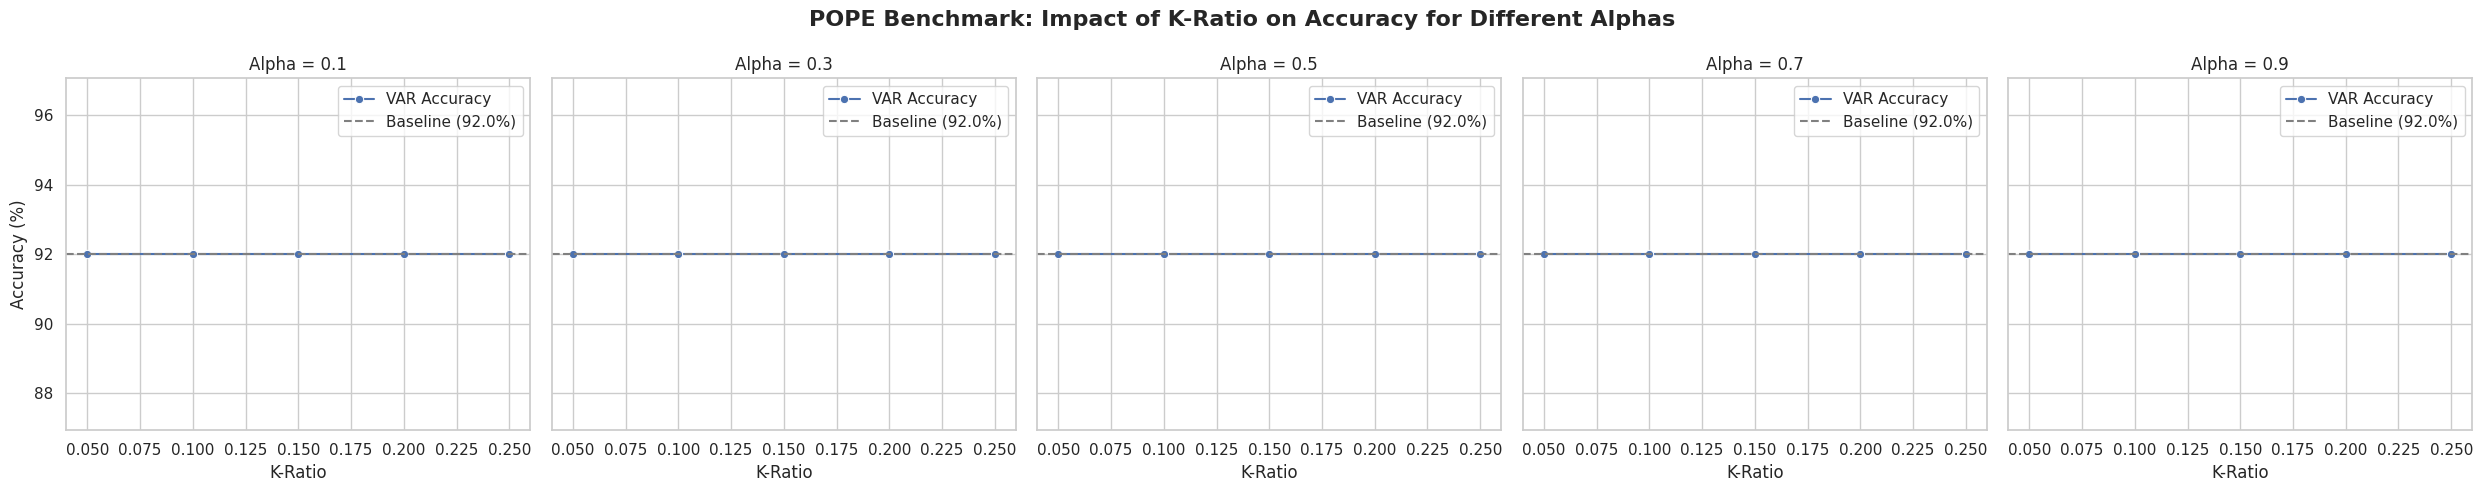

In [34]:
# Cell 6: POPE Evaluation and Visualization
import os
import json
import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

pope_path = "/content/POPE_Final_Subset" # Must match the path from Cell 5

# Find all JSONL files generated by our search
file_pattern = os.path.join(pope_path, "pope_*_answers.jsonl")
jsonl_files = glob.glob(file_pattern)

if not jsonl_files:
    print(f"No JSONL files found in {pope_path}. Did the previous cell run successfully?")
else:
    results_data = []

    print("📊 EVALUATING POPE RESULTS 📊\n")

    for file_path in jsonl_files:
        filename = os.path.basename(file_path)

        # Parse hyperparameters from filename using regex
        # Baseline check
        if "baseline" in filename:
            alpha, k_ratio = 0.0, 0.0
            config_name = "Baseline"
        else:
            match = re.search(r"pope_var_a([0-9.]+)_k([0-9.]+)_answers", filename)
            if match:
                alpha = float(match.group(1))
                k_ratio = float(match.group(2))
                config_name = f"a={alpha}, k={k_ratio}"
            else:
                continue # Skip files that don't match our format

        # Read JSONL
        with open(file_path, 'r', encoding='utf-8') as f:
            answers = [json.loads(line) for line in f if line.strip()]

        pred_list, label_list = [], []

        for item in answers:
            # Ground truth
            gt = str(item.get('label', '')).lower().strip()
            label_list.append(0 if gt == 'no' else 1)

            # Model prediction
            text = str(item.get('response', '')).strip()
            if '.' in text:
                text = text.split('.')[0]
            words = text.replace(',', '').split(' ')

            if 'No' in words or 'not' in words or 'no' in words:
                pred_list.append(0)
            else:
                pred_list.append(1)

        # Calculate metrics
        pos, neg = 1, 0
        TP, TN, FP, FN = 0, 0, 0, 0

        for pred, label in zip(pred_list, label_list):
            if pred == pos and label == pos: TP += 1
            elif pred == pos and label == neg: FP += 1
            elif pred == neg and label == neg: TN += 1
            elif pred == neg and label == pos: FN += 1

        precision = TP / (TP + FP) if (TP + FP) > 0 else 0
        recall = TP / (TP + FN) if (TP + FN) > 0 else 0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
        acc = (TP + TN) / (TP + TN + FP + FN) if (TP + TN + FP + FN) > 0 else 0

        # Append to results
        results_data.append({
            "Config": config_name,
            "Alpha": alpha,
            "K_Ratio": k_ratio,
            "Accuracy": acc * 100,
            "Precision": precision * 100,
            "Recall": recall * 100,
            "F1": f1 * 100
        })

        print(f"[{config_name:^15}] Acc: {acc*100:.2f}% | Prec: {precision*100:.2f}% | Rec: {recall*100:.2f}%")

    # ==========================================
    # VISUALIZATION (GRAPHS)
    # ==========================================
    df = pd.DataFrame(results_data)

    # Filter out baseline for the line/scatter plots
    df_var = df[df["Config"] != "Baseline"].copy()

    # Get unique alphas
    alphas = sorted(df_var["Alpha"].unique())

    # Set up matplotlib figure
    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(1, len(alphas), figsize=(5 * len(alphas), 5), sharey=True)
    fig.suptitle('POPE Benchmark: Impact of K-Ratio on Accuracy for Different Alphas', fontsize=16, fontweight='bold')

    # Check if we have baseline to plot as a reference line
    baseline_acc = None
    baseline_row = df[df["Config"] == "Baseline"]
    if not baseline_row.empty:
        baseline_acc = baseline_row["Accuracy"].values[0]

    # Ensure axes is iterable even if there's only 1 alpha
    if len(alphas) == 1:
        axes = [axes]

    for i, alpha_val in enumerate(alphas):
        ax = axes[i]
        subset = df_var[df_var["Alpha"] == alpha_val].sort_values("K_Ratio")

        # Plot Accuracy vs K-Ratio for this specific alpha
        sns.lineplot(data=subset, x="K_Ratio", y="Accuracy", marker="o", ax=ax, color="b", label="VAR Accuracy")

        if baseline_acc is not None:
            ax.axhline(baseline_acc, ls='--', color='gray', label=f'Baseline ({baseline_acc:.1f}%)')

        ax.set_title(f'Alpha = {alpha_val}')
        ax.set_xlabel('K-Ratio')
        if i == 0:
            ax.set_ylabel('Accuracy (%)')
        else:
            ax.set_ylabel('')
        ax.legend()

    plt.tight_layout()
    plt.show()

In [1]:
# Install dependencies
!pip install -q transformers accelerate bitsandbytes pillow torch torchvision tqdm sentencepiece

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 42.4 MB/s eta 0:00:00


In [2]:
import torch
from transformers import LlavaProcessor, LlavaForConditionalGeneration, BitsAndBytesConfig

# Define the model ID
model_id = "llava-hf/llava-1.5-7b-hf"

# Configure 4-bit quantization
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16
)

print("Loading Processor...")
processor = LlavaProcessor.from_pretrained(model_id)

print("Loading Model in 4-bit (this may take a minute)...")
model = LlavaForConditionalGeneration.from_pretrained(
    model_id,
    quantization_config=bnb_config,
    device_map="auto"
)

model.eval()

print("Model loaded successfully!")

Loading Processor...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


processor_config.json:   0%|          | 0.00/173 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/701 [00:00<?, ?B/s]

chat_template.jinja:   0%|          | 0.00/674 [00:00<?, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/686 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/141 [00:00<?, ?B/s]

Model loaded successfully!


In [5]:
import os

# Unzip MME subset
if not os.path.exists("/content/MME"):
    !unzip -q /content/MME.zip -d /content/MME

# Unzip POPE subset
if not os.path.exists("/content/POPE"):
    !unzip -q /content/POPE.zip -d /content/POPE

# Unzip MMVP subset
if not os.path.exists("/content/MMVP"):
    !unzip -q /content/MMVP.zip -d /content/MMVP

In [6]:
import json
from PIL import Image
from tqdm import tqdm

def generate_benchmark_answers(benchmark_dir, question_filename, output_filename, model_id_name="llava-v1.5-7b"):

    input_jsonl_path = os.path.join(benchmark_dir, "Questions", question_filename)
    output_jsonl_path = os.path.join(benchmark_dir, output_filename)
    images_dir = os.path.join(benchmark_dir, "Images")

    if not os.path.exists(input_jsonl_path):
        print(f"Warning: {input_jsonl_path} not found. Skipping...")
        return

    # Load data
    data = []
    with open(input_jsonl_path, 'r', encoding='utf-8') as f:
        for line in f:
            if line.strip():
                data.append(json.loads(line.strip()))

    print(f"Loaded {len(data)} questions from {input_jsonl_path}")

    with open(output_jsonl_path, 'w', encoding='utf-8') as outfile:
        for item in tqdm(data, desc=f"Processing {os.path.basename(benchmark_dir)}"):

            image_filename = item.get("image", "")
            prompt_text = item.get("text", item.get("question", "")).strip()

            if not prompt_text:
                continue

            # Resolve image path robustly
            img_path = os.path.join(images_dir, image_filename)
            if not os.path.exists(img_path):
                img_path = os.path.join(benchmark_dir, image_filename)

            # Load image
            try:
                raw_image = Image.open(img_path).convert("RGB")
            except Exception as e:
                print(f"\nError loading image {img_path}: {e}. Skipping...")
                continue

            # Prompt format
            full_prompt = f"USER: <image>\n{prompt_text}\nASSISTANT:"

            # Process inputs (FIXED DEVICE HANDLING)
            inputs = processor(
                text=full_prompt,
                images=raw_image,
                return_tensors="pt"
            )

            inputs = {k: v.to(model.device) for k, v in inputs.items()}

            # Generate
            with torch.inference_mode():
                output_ids = model.generate(
                    **inputs,
                    max_new_tokens=50,
                    temperature=0.0,
                    do_sample=False
                )

            # Decode (CLEANED)
            generated_text = processor.decode(output_ids[0], skip_special_tokens=True)
            response_text = generated_text.split("ASSISTANT:")[-1].strip()

            # Output structure
            output_item = {
                "question_id": item.get("question_id", ""),
                "prompt": prompt_text,
                "label": item.get("label", ""),
                "response": response_text,
                "image": image_filename,
                "model_id": model_id_name
            }

            outfile.write(json.dumps(output_item) + "\n")

    print(f"Finished! Answers saved to {output_jsonl_path}")

In [7]:
benchmarks = [
    {
        "name": "MME",
        "path": "/content/MME",
        "questions_file": "mme-questions.jsonl"
    },
    {
        "name": "MMVP",
        "path": "/content/MMVP",
        "questions_file": "mmvp-questions.jsonl"
    },
    {
        "name": "POPE",
        "path": "/content/POPE",
        "questions_file": "pope-questions.jsonl"
    }
]

for bm in benchmarks:
    print(f"\n==========================================")
    print(f"Starting inference for {bm['name']}...")

    output_filename = f"{bm['name'].lower()}_llava_v1_5_7b_answers.jsonl"

    generate_benchmark_answers(
        benchmark_dir=bm["path"],
        question_filename=bm["questions_file"],
        output_filename=output_filename,
        model_id_name="llava-v1.5-7b"
    )

print("\nAll benchmarks processed successfully!")


Starting inference for MME...
Loaded 200 questions from /content/MME/Questions/mme-questions.jsonl


Processing MME: 100%|██████████| 200/200 [01:19<00:00,  2.53it/s]


Finished! Answers saved to /content/MME/mme_llava_v1_5_7b_answers.jsonl

Starting inference for MMVP...
Loaded 300 questions from /content/MMVP/Questions/mmvp-questions.jsonl


Processing MMVP: 100%|██████████| 300/300 [03:49<00:00,  1.31it/s]


Finished! Answers saved to /content/MMVP/mmvp_llava_v1_5_7b_answers.jsonl

Starting inference for POPE...
Loaded 80 questions from /content/POPE/Questions/pope-questions.jsonl


Processing POPE: 100%|██████████| 80/80 [02:28<00:00,  1.86s/it]

Finished! Answers saved to /content/POPE/pope_llava_v1_5_7b_answers.jsonl

All benchmarks processed successfully!


In [8]:
# Evaluate MME Results

from collections import defaultdict


result_file = "/content/MME/mme_llava_v1_5_7b_answers.jsonl"

if not os.path.exists(result_file):
    print(f"Could not find the MME jsonl file at {result_file}. Please check the path or run inference first!")
else:
    print(f"Evaluating MME Benchmark for: {result_file}\n")
    print("-" * 50)


    with open(result_file, 'r', encoding='utf-8') as f:
        answers = [json.loads(line) for line in f if line.strip()]


    results_by_category = defaultdict(lambda: defaultdict(list))

    for item in answers:

        gt = str(item.get('label', '')).lower().strip()


        text = str(item.get('response', '')).lower().strip()


        if '.' in text:
            text = text.split('.')[0]
        text = text.replace(',', '').split(' ')

        if 'no' in text or 'not' in text:
            pred = 'no'
        else:
            pred = 'yes'

        is_correct = (pred == gt)


        image_path = item.get('image', 'unknown.jpg')

        if '/' in image_path:
            category = image_path.split('/')[-2]
            img_id = image_path.split('/')[-1]
        else:
            category = 'Overall'
            img_id = image_path


        if 'category' in item:
            category = item['category']

        results_by_category[category][img_id].append(is_correct)


    total_acc_sum = 0
    total_acc_plus_sum = 0

    print(f"{'Category':<20} | {'Accuracy':<10} | {'Accuracy+':<10} | {'Score (Max 200)':<10}")
    print("-" * 60)

    for category, images in results_by_category.items():
        total_questions = 0
        correct_questions = 0

        total_images = 0
        correct_images = 0

        for img_id, outcomes in images.items():
            total_images += 1
            total_questions += len(outcomes)
            correct_questions += sum(outcomes)


            if len(outcomes) == 2 and sum(outcomes) == 2:
                correct_images += 1


        acc = (correct_questions / total_questions) * 100 if total_questions > 0 else 0
        acc_plus = (correct_images / total_images) * 100 if total_images > 0 else 0
        score = acc + acc_plus

        total_acc_sum += acc
        total_acc_plus_sum += acc_plus

        print(f"{category:<20} | {acc:<10.2f} | {acc_plus:<10.2f} | {score:<10.2f}")

    print("-" * 60)


    num_categories = len(results_by_category)
    if num_categories > 0:
        avg_acc = total_acc_sum / num_categories
        avg_acc_plus = total_acc_plus_sum / num_categories
        total_score = total_acc_sum + total_acc_plus_sum
        print(f"{'TOTAL / AVERAGE':<20} | {avg_acc:<10.2f} | {avg_acc_plus:<10.2f} | {total_score:<10.2f}")

Evaluating MME Benchmark for: /content/MME/mme_llava_v1_5_7b_answers.jsonl

--------------------------------------------------
Category             | Accuracy   | Accuracy+  | Score (Max 200)
------------------------------------------------------------
Overall              | 72.50      | 47.00      | 119.50    
------------------------------------------------------------
TOTAL / AVERAGE      | 72.50      | 47.00      | 119.50    


In [9]:
# Evaluate POPE Results

result_file = "/content/POPE/pope_llava_v1_5_7b_answers.jsonl"

if not os.path.exists(result_file):
    print(f"Could not find the POPE jsonl file at {result_file}. Please check the path or run inference first!")
else:
    print(f"✅ Found file! Evaluating: {result_file}\n")
    print("-" * 50)

    with open(result_file, 'r', encoding='utf-8') as f:
        answers = [json.loads(line) for line in f if line.strip()]

    pred_list = []
    label_list = []

    for item in answers:

        gt = str(item.get('label', '')).lower().strip()
        label_list.append(0 if gt == 'no' else 1)


        text = str(item.get('response', '')).strip()


        if '.' in text:
            text = text.split('.')[0]

        text = text.replace(',', '')
        words = text.split(' ')


        if 'No' in words or 'not' in words or 'no' in words:
            pred_list.append(0)
        else:
            pred_list.append(1)

    pos, neg = 1, 0
    yes_ratio = pred_list.count(1) / len(pred_list) if pred_list else 0

    TP, TN, FP, FN = 0, 0, 0, 0
    for pred, label in zip(pred_list, label_list):
        if pred == pos and label == pos:
            TP += 1
        elif pred == pos and label == neg:
            FP += 1
        elif pred == neg and label == neg:
            TN += 1
        elif pred == neg and label == pos:
            FN += 1

    print('TP\tFP\tTN\tFN')
    print(f'{TP}\t{FP}\t{TN}\t{FN}\n')

    precision = float(TP) / float(TP + FP) if (TP + FP) > 0 else 0
    recall = float(TP) / float(TP + FN) if (TP + FN) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    acc = (TP + TN) / (TP + TN + FP + FN) if (TP + TN + FP + FN) > 0 else 0

    print(f'Accuracy:  {acc:.4f}')
    print(f'Precision: {precision:.4f}')
    print(f'Recall:    {recall:.4f}')
    print(f'F1 score:  {f1:.4f}')
    print(f'Yes ratio: {yes_ratio:.4f}')
    print("-" * 50)

✅ Found file! Evaluating: /content/POPE/pope_llava_v1_5_7b_answers.jsonl

--------------------------------------------------
TP	FP	TN	FN
34	6	34	6

Accuracy:  0.8500
Precision: 0.8500
Recall:    0.8500
F1 score:  0.8500
Yes ratio: 0.5000
--------------------------------------------------
